**Final - Bagging Classifier with SVC (Ensemble Model)**

Bu çalışmada, KNN ve SVM gibi tekil öğrenicilerin varyansını düşürmek ve tahmin kararlılığını artırmak için Bagging topluluk öğrenmesi tekniği kullanılmıştır. Kod akışı; verinin hazırlanması, base learner (temel öğrenici) olarak SVC'nin tanımlanması, bootstrap örnekleme metoduyla topluluk modelinin oluşturulması ve modelin ayırt edici gücünün metrikler üzerinden görselleştirilmesi basamaklarını takip etmektedir.

In [ ]:
# Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

# Görselleştirme ayarı
sns.set_style("whitegrid")

Veri Seti Boyutu: (13028, 69)


/tmp/ipython-input-3026807886.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')


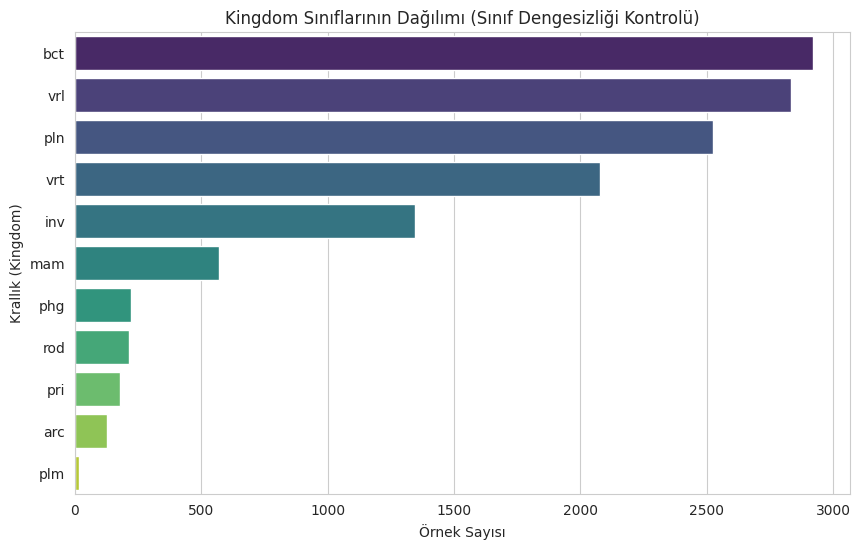

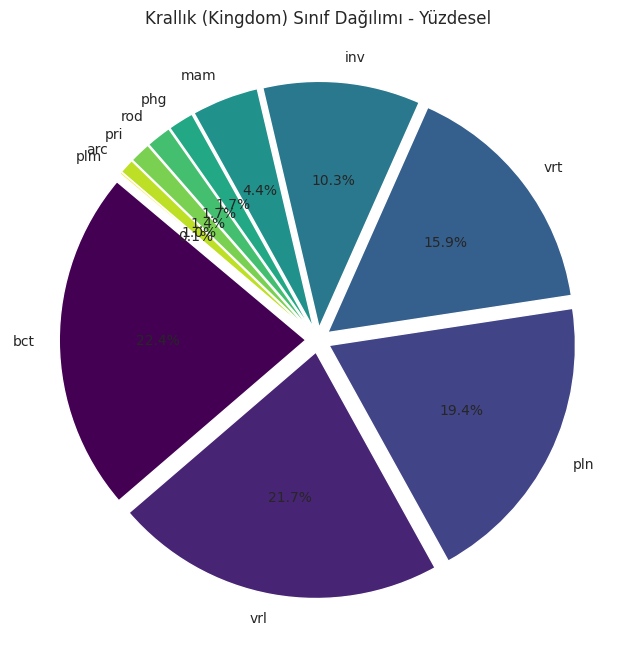

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [ ]:
# Veri setinin yüklenmesi
df = pd.read_csv("codon_usage.csv", low_memory=False)

print("Veri Seti Boyutu:", df.shape)

# Kingdom sınıf dağılımının görselleştirilmesi
plt.figure(figsize=(10, 6))
sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')
plt.title('Kingdom Sınıflarının Dağılımı (Sınıf Dengesizliği Kontrolü)')
plt.xlabel('Örnek Sayısı')
plt.ylabel('Krallık (Kingdom)')
plt.show()

# Pasta grafiğinin eklenmesi
plt.figure(figsize=(10, 8))
df['Kingdom'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='viridis',
    explode=[0.05] * len(df['Kingdom'].unique())
)
plt.title('Krallık (Kingdom) Sınıf Dağılımı - Yüzdesel')
plt.ylabel('') # Y ekseni etiketini temizleme islemi
plt.show()

# İlk 5 satırı göster:
display(df.head())

In [ ]:
# Ön tanımlama islemleri
# Kodon sütunları (5. sütundan itibaren)
codon_cols = df.columns[5:]
# Diğer sayısal sütunlar (Ncodons, DNAtype)
other_numeric_cols = ['Ncodons', 'DNAtype']
# Tüm sayısal özellikler
numeric_features = list(codon_cols) + other_numeric_cols

print("Temizlik Başlangıcı:")
for col in numeric_features:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )

# İhtiyaç olmayan tanımlayıcı sütunları çıkar
df_cleaned = df.drop(columns=['SpeciesID', 'SpeciesName']).copy()

--- Temizlik Başlangıcı ---


In [ ]:
# 4. Veri ayırma (Split) - Imputation'dan önce
X = df_cleaned.drop(columns=['Kingdom'])
y = df_cleaned['Kingdom']

# %80 Eğitim / %20 Test, Krallığa göre katmanlı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Eğitim ve test setlerini tek DataFrame'lerde birleştirme
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("\n Veri Ayırma Sonuçları : ")
print(f"X_train Boyutu: {X_train.shape}")
print(f"X_test Boyutu: {X_test.shape}")


--- Veri Ayırma Sonuçları ---
X_train Boyutu: (10422, 66)
X_test Boyutu: (2606, 66)


In [ ]:
# 5. Eksik değer doldurma (Imputation)

# Train setindeki her bir sayısal sütunun ortalamasını hesapla
# Bu ortalamayı, hem Train hem de Test setini doldurmak için kullanma işlemi
train_means = train_df[numeric_features].mean()

# Train ve Test setlerini, Train setinin ortalamaları ile doldur
train_df[numeric_features] = train_df[numeric_features].fillna(train_means)
test_df[numeric_features] = test_df[numeric_features].fillna(train_means)

print("Eksik Değer Doldurma Tamamlandı. Test seti, Train ortalaması ile dolduruldu.")

# Encoding (Hedef Değişken Kodlama) kısmı
le = LabelEncoder()
train_df['Kingdom_Encoded'] = le.fit_transform(train_df['Kingdom'])
test_df['Kingdom_Encoded'] = le.transform(test_df['Kingdom'])

print("Krallık Kodlaması:", dict(zip(le.classes_, le.transform(le.classes_))))

# Scaling (Ölçeklendirme) İşlemi
scaler = StandardScaler()

# Scaler'ı sadece eğitim verisine fit et
scaler.fit(train_df[numeric_features])

# Train ve Test setlerini ölçekle
train_df[numeric_features] = scaler.transform(train_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])

print("Ölçeklendirme Tamamlandı. Ncodons ve Kodonlar Standardize Edildi.")

Eksik Değer Doldurma Tamamlandı. Test seti, Train ortalaması ile dolduruldu.
Krallık Kodlaması: {'arc': np.int64(0), 'bct': np.int64(1), 'inv': np.int64(2), 'mam': np.int64(3), 'phg': np.int64(4), 'plm': np.int64(5), 'pln': np.int64(6), 'pri': np.int64(7), 'rod': np.int64(8), 'vrl': np.int64(9), 'vrt': np.int64(10)}
Ölçeklendirme Tamamlandı. Ncodons ve Kodonlar Standardize Edildi.


In [ ]:
# 6. Nihai X ve y setlerini oluştur
X_train_final = train_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_train_final = train_df['Kingdom_Encoded']
X_test_final = test_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_test_final = test_df['Kingdom_Encoded']

# Sonuçları CSV olarak kaydet
X_train_final.to_csv('X_train_final_Adim.csv', index=False)
X_test_final.to_csv('X_test_final_Adim.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_train_final.values, 'Kingdom_Original': train_df['Kingdom'].values}).to_csv('y_train_encoded_final_Adim.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_test_final.values, 'Kingdom_Original': test_df['Kingdom'].values}).to_csv('y_test_encoded_final_Adim.csv', index=False)

print("Tüm hazırlık adımları tamamlandı. Veriler dosyalara kaydedildi.")

Tüm hazırlık adımları tamamlandı. Veriler dosyalara kaydedildi.


In [ ]:
# ENSEMBLE MODELLER İÇİN ORTAK FE
gc_rich_codons = ['GGU', 'GGC', 'GGA', 'GGG', 'GCU', 'GCC', 'GCA', 'GCG', 'CCU', 'CCC', 'CCA', 'CCG', 'CGU', 'CGC', 'CGA', 'CGG', 'UGU', 'UGC', 'GAU', 'GAC', 'GAA', 'GAG', 'CAU', 'CAC', 'CAA', 'CAG', 'AAG', 'AGG', 'UGG']
at_rich_codons = ['UUU', 'UUC', 'UUA', 'UUG', 'AUU', 'AUC', 'AUA', 'AAA', 'AAU', 'AAC', 'UAU', 'UAC', 'UAA', 'UAG', 'UGA']

existing_cols = X_train_final.columns
gc_cols = [c for c in existing_cols if c in gc_rich_codons]
at_cols = [c for c in existing_cols if c in at_rich_codons]

# yeni sütunların türetilmesi
X_train_final['GC_SCORE'] = X_train_final[gc_cols].sum(axis=1)
X_test_final['GC_SCORE'] = X_test_final[gc_cols].sum(axis=1)

at_sum_train = X_train_final[at_cols].sum(axis=1) + 1e-6
at_sum_test = X_test_final[at_cols].sum(axis=1) + 1e-6

X_train_final['GC_AU_RATIO'] = X_train_final['GC_SCORE'] / at_sum_train
X_test_final['GC_AU_RATIO'] = X_test_final['GC_SCORE'] / at_sum_test

print(f"FE Tamamlandı. Yeni Özelliklerle Toplam Sütun Sayısı: {X_train_final.shape[1]}")

FE Tamamlandı. Yeni Özelliklerle Toplam Sütun Sayısı: 68


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Temel Model (Base estimator) tanımlama
# probability=true, ROC Curve çizmek için olasılık skorlarına ihtiyac var
base_svc = SVC(kernel='rbf', probability=True, random_state=42)

# Bagging classifier tanımlama
bagging_svc_model = BaggingClassifier(estimator=base_svc, random_state=42)

# Hiperparametre havuzu (Tuning islemi icin)
# n_estimators: Kaç tane SVC'nin oylamaya katılacağı
# max_samples: Her bir SVC için kullanılacak veri oranı
param_grid_bagging = {
    'n_estimators': [5, 10],
    'max_samples': [0.7, 1.0],
    'bootstrap': [True]
}

# Grid search uygulanan alan
grid_search_bagging = GridSearchCV(
    estimator=bagging_svc_model,
    param_grid=param_grid_bagging,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_bagging.fit(X_train_final, y_train_final)

# sonuçlar
print("\n Bagging (SVC) optimum parametreler")
print("En iyi parametreler:", grid_search_bagging.best_params_)
print("En iyi doğruluk skoru:", grid_search_bagging.best_score_)

# En iyi modeli seçme
best_bagging_svc = grid_search_bagging.best_estimator_

Bagging (SVC) optimizasyonu başlatılıyor... Bu işlem veri boyutuna göre 5-10 dakika sürebilir.
Fitting 3 folds for each of 4 candidates, totalling 12 fits

--- Bagging (SVC) Optimum Parametreler ---
En iyi parametreler: {'bootstrap': True, 'max_samples': 1.0, 'n_estimators': 10}
En iyi doğruluk skoru: 0.7109959700633275


--- BAGGING (SVC) GENEL PERFORMANS ---
Accuracy:  0.6903
Precision: 0.7014
Recall:    0.6903
F1 Score:  0.6878

--- BAGGING (SVC) SINIF BAZLI PERFORMANS ---
              precision    recall  f1-score   support

         arc       0.60      0.48      0.53        25
         bct       0.86      0.88      0.87       584
         inv       0.38      0.31      0.34       269
         mam       0.73      0.72      0.73       114
         phg       0.90      0.59      0.71        44
         plm       0.00      0.00      0.00         4
         pln       0.67      0.62      0.64       505
         pri       0.72      0.36      0.48        36
         rod       0.90      0.42      0.57        43
         vrl       0.55      0.76      0.64       567
         vrt       0.89      0.74      0.81       415

    accuracy                           0.69      2606
   macro avg       0.66      0.53      0.58      2606
weighted avg       0.70      0.69      0.69      2606



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

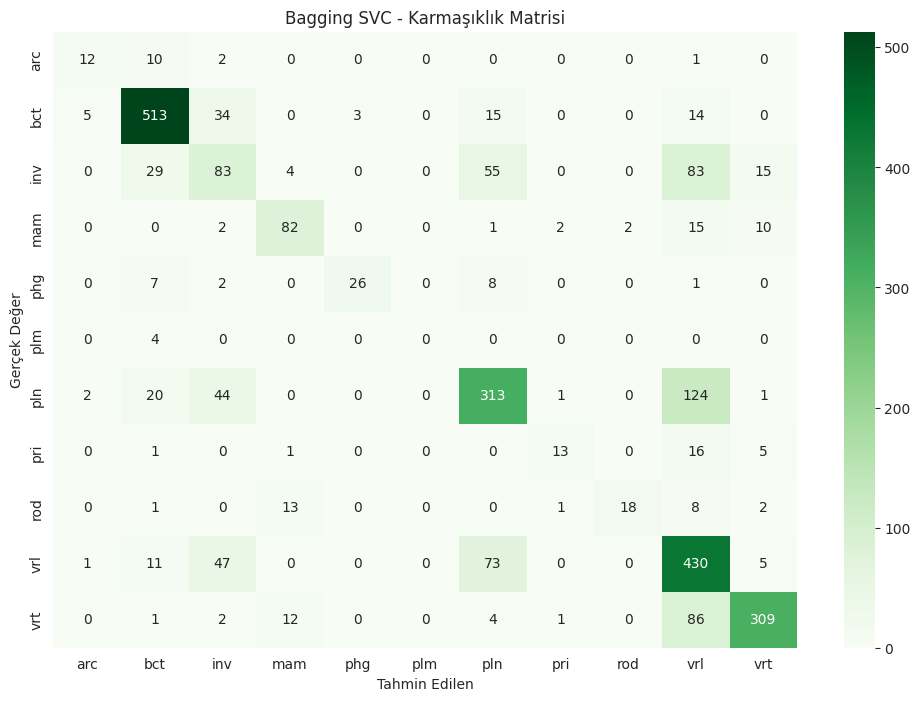

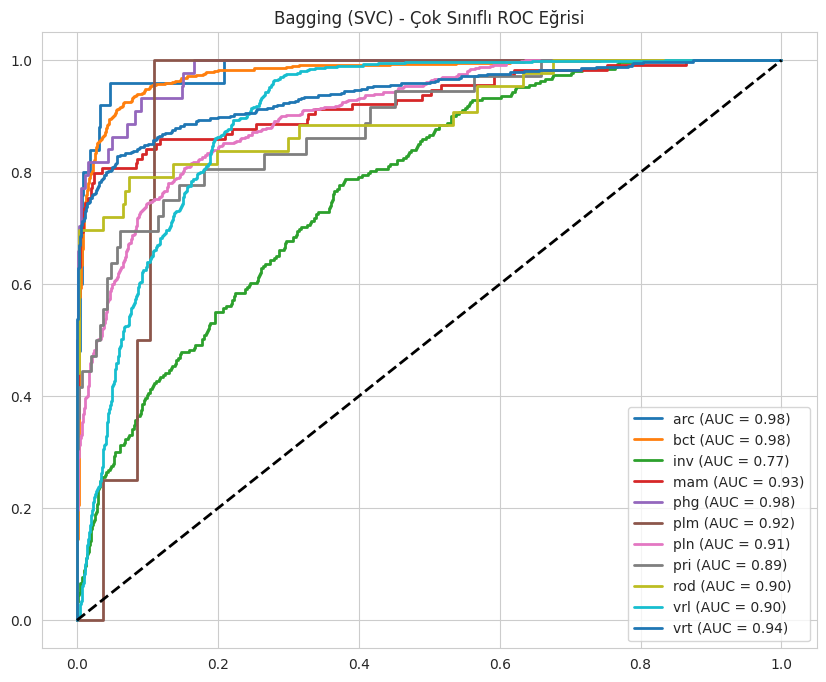

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Tahminler kısmı
y_pred_bag = best_bagging_svc.predict(X_test_final)
y_prob_bag = best_bagging_svc.predict_proba(X_test_final)

# 2. Genel Metriklerin olusumu
print(" BAGGING (SVC) GENEL PERFORMANS")
print(f"Accuracy:  {accuracy_score(y_test_final, y_pred_bag):.4f}")
print(f"Precision: {precision_score(y_test_final, y_pred_bag, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_final, y_pred_bag, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test_final, y_pred_bag, average='weighted'):.4f}")

# Sınıf Bazlı Kırılım
print("\n BAGGING (SVC) SINIF BAZLI PERFORMANS")
print(classification_report(y_test_final, y_pred_bag, target_names=le.classes_))

# Bagging SVC karmaşıklık matrisi hesabı ve görselleştirme islemi
cm_bag = confusion_matrix(y_test_final, y_pred_bag)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_bag, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Bagging SVC - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

# 4. ROC eğrisi cizimi
y_test_bin = label_binarize(y_test_final, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_bag[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Bagging (SVC) - Çok Sınıflı ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')